# Experiment: Loss Function Comparison for Jaguar Re-Identification

This notebook builds on the **baseline pipeline** (MegaDescriptor + ArcFace) and performs a **systematic comparison of loss functions** to determine the best metric learning objective.

## Hypothesis
Different loss functions impose different geometric constraints on the embedding space. Comparing ArcFace (angular margin), CosFace (additive cosine margin), and Triplet Loss (pairwise distance) will reveal which objective best separates jaguar identities.

## Loss Functions Compared
1. **ArcFace** (Additive Angular Margin) — adds angular margin to ground truth class angle (baseline)
2. **CosFace** (Additive Cosine Margin) — adds cosine margin directly to cosine similarity
3. **Triplet Loss** — optimizes relative distances: anchor-positive < anchor-negative by a margin

## Methodology
- Each loss function trains a fresh model for **20 epochs** (reduced from 50) to efficiently compare
- The **best loss function** is then trained for the full 50 epochs
- All metrics are logged to W&B for dashboard comparison

## Comparability to Baseline
- Same MegaDescriptor-L-384 backbone (frozen)
- Same EmbeddingProjection architecture (1536 → 512 → 256)
- Same train/val split (stratified, seed=42)
- Same validation mAP computation
- Same data (no augmentation — same as baseline)
- Same optimizer (AdamW, lr=1e-4) and scheduler (ReduceLROnPlateau)
- **Only difference**: Loss function used for training

## 1. Setup and Configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import copy
import json
import wandb
from dotenv import load_dotenv

# Load environment variables from .env file
env_path = Path("../../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"] = user_secrets.get_secret("hf_api")
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")
except ImportError:
    print("Not running on Kaggle, using local .env for secrets.")

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

PyTorch version: 2.9.0+cu126
timm version: 1.0.24
Using CUDA GPU
Device: cuda


In [2]:
# ── Base Configuration (IDENTICAL to baseline) ──
base_config = {
    # Paths
    "data_dir": Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints_loss"),

    # Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "embedding_dim": 256,
    "hidden_dim": 512,

    # ArcFace (baseline loss defaults)
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,

    # Reproducibility
    "seed": RANDOM_SEED,
}

# ── Sweep settings ──
SWEEP_EPOCHS = 20          # reduced epochs for sweep runs
SWEEP_PATIENCE = 7         # reduced patience for sweep runs
FULL_TRAIN_EPOCHS = 50     # full epochs for the best configuration

# Create checkpoint directory
base_config["checkpoint_dir"].mkdir(exist_ok=True)

print("Base Configuration (same as baseline):")
for key, value in base_config.items():
    print(f"  {key}: {value}")
print(f"\nSweep settings:")
print(f"  Sweep epochs: {SWEEP_EPOCHS}")
print(f"  Sweep patience: {SWEEP_PATIENCE}")
print(f"  Full train epochs: {FULL_TRAIN_EPOCHS}")

Base Configuration (same as baseline):
  data_dir: /kaggle/input/competitions/jaguar-re-id
  checkpoint_dir: checkpoints_loss
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  seed: 42

Sweep settings:
  Sweep epochs: 20
  Sweep patience: 7
  Full train epochs: 50


In [3]:
# Initialize W&B
wandb.login(key=os.environ["WANDB_API_KEY"])
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "Jaguar-Re-identification-Challenge")
print(f"W&B project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: finnfrei (finnfreiheit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B project: Jaguar-Re-identification-Challenge


## 2. Load and Prepare Data

In [4]:
# Load training data
train_df = pd.read_csv(base_config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1


In [5]:
# Encode labels and create stratified train/validation split
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size=base_config["val_split"],
    random_state=base_config["seed"],
    stratify=train_df['ground_truth']
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-base_config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*base_config['val_split']:.0f}%)")
print(f"  Num classes: {num_classes}")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())
assert train_identities == val_identities, "Not all identities in both sets!"
print(f"  All {len(train_identities)} identities present in both sets ✓")

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)
  Num classes: 31
  All 31 identities present in both sets ✓


## 3. Load MegaDescriptor and Extract Embeddings

In [6]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    base_config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)

print(f"Model loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in megadescriptor.parameters()):,}")

# Get the embedding dimension from the model
with torch.no_grad():
    dummy_input = torch.randn(1, 3, base_config["input_size"], base_config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Model loaded successfully
  Parameters: 195,198,516
  Embedding dimension: 1536


In [7]:
# Preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((base_config["input_size"], base_config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using MegaDescriptor."""
    model.eval()
    embeddings = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]

        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                batch_tensors.append(torch.zeros(3, base_config["input_size"], base_config["input_size"]))

        batch_tensor = torch.stack(batch_tensors).to(device)
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)

    return np.vstack(embeddings)

print("Embedding extraction function defined")

Embedding extraction function defined


In [8]:
# Extract and cache embeddings for training and validation sets

# Training embeddings
train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [base_config["data_dir"] / "train/train" / fn for fn in train_filenames]

emb_dir = Path("/kaggle/working/embeddings")
emb_dir.mkdir(parents=True, exist_ok=True)
cache_path = emb_dir / "loss_experiment_train_embeddings.npz"

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])
    if len(cached_filenames) != len(expected_filenames):
        return None
    if set(cached_filenames) != set(expected_filenames):
        return None
    if cached_filenames == expected_filenames:
        return cached_embeddings
    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

baseline_train_embeddings = None
if cache_path.exists():
    baseline_train_embeddings = _load_cached_embeddings(cache_path, train_filenames)
    if baseline_train_embeddings is not None:
        print(f"Loaded cached train embeddings from {cache_path}")

if baseline_train_embeddings is None:
    print(f"Extracting embeddings for {len(train_image_paths)} training images...")
    baseline_train_embeddings = extract_embeddings(
        megadescriptor, train_image_paths, batch_size=base_config["batch_size"]
    )
    np.savez_compressed(cache_path, embeddings=baseline_train_embeddings, filenames=np.array(train_filenames, dtype=object))
    print(f"Saved train embeddings cache to {cache_path}")

print(f"Train embeddings shape: {baseline_train_embeddings.shape}")

# Validation embeddings
val_image_paths = [base_config["data_dir"] / "train/train" / fn for fn in val_data['filename'].values]

print(f"Extracting embeddings for {len(val_image_paths)} validation images...")
baseline_val_embeddings = extract_embeddings(
    megadescriptor, val_image_paths, batch_size=base_config["batch_size"]
)
print(f"Val embeddings shape: {baseline_val_embeddings.shape}")

Extracting embeddings for 1516 training images...


Extracting embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Saved train embeddings cache to /kaggle/working/embeddings/loss_experiment_train_embeddings.npz
Train embeddings shape: (1516, 1536)
Extracting embeddings for 379 validation images...


Extracting embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Val embeddings shape: (379, 1536)


## 4. Define Model Architecture and Loss Functions

We define the shared **EmbeddingProjection** (identical to baseline) and three loss function variants:

1. **ArcFaceLayer** — Additive Angular Margin: $\cos(\theta_{y} + m)$ penalizes ground truth angle
2. **CosFaceLayer** — Additive Cosine Margin: $\cos(\theta_{y}) - m$ penalizes ground truth cosine directly
3. **TripletLoss** — Optimizes relative distances: $d(a,p) + m < d(a,n)$ for (anchor, positive, negative) triplets

### Key Differences

| Property | ArcFace | CosFace | Triplet Loss |
|----------|---------|---------|-------------|
| Margin Type | Angular (additive to angle) | Cosine (subtractive from cosine) | Distance-based |
| Requires Class Labels | Yes (classification) | Yes (classification) | Yes (for mining) |
| Optimization Space | Hypersphere (angular) | Hypersphere (cosine) | Euclidean/cosine |
| Loss Function | CrossEntropy on scaled logits | CrossEntropy on scaled logits | Hinge loss on triplets |
| Gradient Signal | From all classes per sample | From all classes per sample | From hardest triplets only |

In [9]:
class EmbeddingProjection(nn.Module):
    """Projects MegaDescriptor embeddings to a lower-dimensional space.
    IDENTICAL to baseline."""

    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)


# ──────────────────────────────────────────────────
# Loss 1: ArcFace (Additive Angular Margin) — BASELINE
# ──────────────────────────────────────────────────
class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.

    Loss: L = -log( exp(s·cos(θ_y + m)) / (exp(s·cos(θ_y + m)) + Σ exp(s·cos(θ_j))) )

    - θ_y: angle between embedding and ground truth class center
    - m: angular margin (default 0.5 rad ≈ 28.6°)
    - s: feature scale (default 64)
    """

    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(embeddings, weight_norm).clamp(-1.0, 1.0)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))

        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale
        return output


# ──────────────────────────────────────────────────
# Loss 2: CosFace (Additive Cosine Margin)
# ──────────────────────────────────────────────────
class CosFaceLayer(nn.Module):
    """
    CosFace (Large Margin Cosine Loss) layer.

    Unlike ArcFace which adds margin in the angular space:
        ArcFace:  cos(θ + m)
    CosFace subtracts margin directly from the cosine similarity:
        CosFace:  cos(θ) - m

    Loss: L = -log( exp(s·(cos(θ_y) - m)) / (exp(s·(cos(θ_y) - m)) + Σ exp(s·cos(θ_j))) )

    - m: cosine margin (default 0.35)
    - s: feature scale (default 64)
    """

    def __init__(self, embedding_dim, num_classes, margin=0.35, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Normalize embeddings and weights
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        # Cosine similarity: cos(θ)
        cosine = F.linear(embeddings, weight_norm).clamp(-1.0, 1.0)

        # Subtract margin from ground truth class: cos(θ_y) - m
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        output = cosine - one_hot * self.margin

        # Scale logits
        output = output * self.scale
        return output


print("Loss layers defined: ArcFaceLayer, CosFaceLayer")

Loss layers defined: ArcFaceLayer, CosFaceLayer


In [10]:
# ──────────────────────────────────────────────────
# Loss 3: Triplet Loss with Online Hard Mining
# ──────────────────────────────────────────────────

class TripletMiner:
    """
    Online hard triplet mining.

    For each anchor, finds:
    - Hardest positive: same-class sample with largest distance
    - Hardest negative: different-class sample with smallest distance

    This focuses training on the most informative triplets.
    """

    @staticmethod
    def get_hard_triplets(embeddings, labels):
        """
        Mine hard triplets from a batch.

        Args:
            embeddings: (B, D) normalized embeddings
            labels: (B,) integer labels

        Returns:
            anchor_idx, positive_idx, negative_idx: indices into the batch
        """
        device = embeddings.device
        embeddings = F.normalize(embeddings, p=2, dim=1)

        # Pairwise distance matrix
        dist_matrix = torch.cdist(embeddings, embeddings, p=2)

        labels = labels.view(-1)
        batch_size = labels.size(0)

        # Create masks
        label_equal = labels.unsqueeze(0) == labels.unsqueeze(1)       # (B, B)
        label_not_equal = ~label_equal

        # Exclude self-pairs from positives
        not_self = ~torch.eye(batch_size, dtype=torch.bool, device=device)
        positive_mask = label_equal & not_self
        negative_mask = label_not_equal

        anchor_indices = []
        positive_indices = []
        negative_indices = []

        for i in range(batch_size):
            # Find valid positives for this anchor
            pos_mask_i = positive_mask[i]
            neg_mask_i = negative_mask[i]

            if pos_mask_i.sum() == 0 or neg_mask_i.sum() == 0:
                continue

            # Hardest positive: max distance among positives
            pos_dists = dist_matrix[i].clone()
            pos_dists[~pos_mask_i] = -1.0  # mask out non-positives
            hardest_pos = pos_dists.argmax()

            # Hardest negative: min distance among negatives
            neg_dists = dist_matrix[i].clone()
            neg_dists[~neg_mask_i] = float('inf')  # mask out non-negatives
            hardest_neg = neg_dists.argmin()

            anchor_indices.append(i)
            positive_indices.append(hardest_pos.item())
            negative_indices.append(hardest_neg.item())

        if len(anchor_indices) == 0:
            return None, None, None

        return (
            torch.tensor(anchor_indices, device=device),
            torch.tensor(positive_indices, device=device),
            torch.tensor(negative_indices, device=device),
        )


class OnlineTripletLoss(nn.Module):
    """
    Online Triplet Loss with hard mining.

    L = max(d(anchor, positive) - d(anchor, negative) + margin, 0)

    Uses online hard mining to select the most informative triplets per batch.
    """

    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
        self.miner = TripletMiner()

    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (B, D) raw embeddings (will be normalized)
            labels: (B,) integer labels

        Returns:
            loss: scalar triplet loss
            num_triplets: number of valid triplets found
        """
        embeddings = F.normalize(embeddings, p=2, dim=1)

        anchor_idx, pos_idx, neg_idx = self.miner.get_hard_triplets(embeddings, labels)

        if anchor_idx is None:
            return torch.tensor(0.0, device=embeddings.device, requires_grad=True), 0

        anchor_emb = embeddings[anchor_idx]
        positive_emb = embeddings[pos_idx]
        negative_emb = embeddings[neg_idx]

        # Euclidean distances
        pos_dist = F.pairwise_distance(anchor_emb, positive_emb, p=2)
        neg_dist = F.pairwise_distance(anchor_emb, negative_emb, p=2)

        # Triplet loss
        losses = F.relu(pos_dist - neg_dist + self.margin)
        loss = losses.mean()

        num_active = (losses > 0).sum().item()
        return loss, num_active


print("TripletMiner and OnlineTripletLoss defined")

TripletMiner and OnlineTripletLoss defined


In [11]:
# ──────────────────────────────────────────────────
# Unified Model Classes
# ──────────────────────────────────────────────────

class MarginLossModel(nn.Module):
    """
    Model for margin-based classification losses (ArcFace, CosFace).
    Architecture: EmbeddingProjection → MarginLayer → CrossEntropy
    """

    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512,
                 margin_layer_class=ArcFaceLayer, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout,
        )
        self.margin_layer = margin_layer_class(
            embedding_dim=embedding_dim,
            num_classes=num_classes,
            margin=margin,
            scale=scale,
        )

    def forward(self, x, labels):
        embeddings = self.embedding_net(x)
        logits = self.margin_layer(embeddings, labels)
        return logits, embeddings

    def get_embeddings(self, x):
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)


class TripletModel(nn.Module):
    """
    Model for triplet loss training.
    Architecture: EmbeddingProjection → L2-normalize → TripletLoss
    No classification head needed — loss is computed directly on embeddings.
    """

    def __init__(self, input_dim, embedding_dim=256, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout,
        )

    def forward(self, x):
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)

    def get_embeddings(self, x):
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)


print("MarginLossModel and TripletModel defined")

MarginLossModel and TripletModel defined


## 5. Training Utilities

In [12]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""

    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


def compute_validation_map(model, val_embeddings, val_labels, device):
    """
    Compute identity-balanced mean Average Precision on validation set.
    IDENTICAL to baseline.
    """
    model.eval()

    with torch.no_grad():
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()

    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)

    query_aps = {}

    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        similarities = sim_matrix[query_idx]

        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0

        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]

        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue

        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives

        query_aps[query_idx] = (query_label, ap)

    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)

    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)

    return balanced_map


# ── Training functions for margin-based losses (ArcFace, CosFace) ──

def train_epoch_margin(model, loader, criterion, optimizer, device):
    """Train for one epoch with margin-based loss (ArcFace/CosFace)."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)

        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch_margin(model, loader, criterion, device):
    """Validate for one epoch with margin-based loss."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings, labels = embeddings.to(device), labels.to(device)

            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


# ── Training functions for triplet loss ──

def train_epoch_triplet(model, loader, triplet_loss_fn, optimizer, device):
    """Train for one epoch with triplet loss."""
    model.train()
    total_loss = 0
    total_triplets = 0
    num_batches = 0

    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)

        # Forward: get normalized embeddings
        projected_embeddings = model(embeddings)

        # Compute triplet loss with online hard mining
        loss, num_active = triplet_loss_fn(projected_embeddings, labels)

        if loss.item() > 0 or loss.requires_grad:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_triplets += num_active
        num_batches += 1

    avg_loss = total_loss / max(num_batches, 1)
    return avg_loss, total_triplets


def validate_epoch_triplet(model, loader, triplet_loss_fn, device):
    """Validate for one epoch with triplet loss."""
    model.eval()
    total_loss = 0
    total_triplets = 0
    num_batches = 0

    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings, labels = embeddings.to(device), labels.to(device)

            projected_embeddings = model(embeddings)
            loss, num_active = triplet_loss_fn(projected_embeddings, labels)

            total_loss += loss.item()
            total_triplets += num_active
            num_batches += 1

    avg_loss = total_loss / max(num_batches, 1)
    return avg_loss, total_triplets


print("Training utilities defined (margin-based and triplet variants)")

Training utilities defined (margin-based and triplet variants)


## 6. Loss Function Sweep Runner

A generic function that trains a model with a given loss function and returns results. Each run gets its own W&B run for comparison.

In [13]:
def run_loss_experiment(
    experiment_name,
    loss_type,
    loss_kwargs,
    train_embeddings,
    train_labels,
    val_embeddings,
    val_labels_gt,
    val_labels_encoded,
    num_classes,
    megadescriptor_dim,
    device,
    num_epochs=SWEEP_EPOCHS,
    patience=SWEEP_PATIENCE,
):
    """
    Train one model with a specific loss function and return results.

    Args:
        experiment_name: name for the W&B run
        loss_type: "arcface", "cosface", or "triplet"
        loss_kwargs: dict of loss-specific hyperparameters
        train_embeddings: numpy array of training embeddings
        train_labels: numpy array of encoded training labels
        val_embeddings: numpy array of validation embeddings
        val_labels_gt: numpy array of ground truth validation labels (strings)
        val_labels_encoded: numpy array of encoded validation labels
        num_classes: number of classes
        megadescriptor_dim: MegaDescriptor embedding dimension
        device: torch device
        num_epochs: number of training epochs
        patience: early stopping patience

    Returns:
        dict with best_val_map, best_val_loss, best_epoch, history
    """
    cfg = {**base_config}

    # Seed for reproducibility
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # Build W&B config
    wandb_config = {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()}
    wandb_config["loss_type"] = loss_type
    wandb_config.update(loss_kwargs)

    run = wandb.init(
        project=WANDB_PROJECT,
        group="loss-comparison",
        config=wandb_config,
        name=experiment_name,
        reinit=True,
    )

    # Create dataloaders
    train_dataset = EmbeddingDataset(train_embeddings, train_labels)
    val_dataset = EmbeddingDataset(val_embeddings, val_labels_encoded)

    # Triplet loss benefits from larger batches to find hard triplets
    batch_size = loss_kwargs.get("batch_size", cfg["batch_size"])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    # Create model and loss depending on type
    if loss_type == "arcface":
        model = MarginLossModel(
            input_dim=megadescriptor_dim,
            num_classes=num_classes,
            embedding_dim=cfg["embedding_dim"],
            hidden_dim=cfg["hidden_dim"],
            margin_layer_class=ArcFaceLayer,
            margin=loss_kwargs.get("margin", 0.5),
            scale=loss_kwargs.get("scale", 64.0),
            dropout=cfg["dropout"],
        ).to(device)
        criterion = nn.CrossEntropyLoss()
        is_triplet = False

    elif loss_type == "cosface":
        model = MarginLossModel(
            input_dim=megadescriptor_dim,
            num_classes=num_classes,
            embedding_dim=cfg["embedding_dim"],
            hidden_dim=cfg["hidden_dim"],
            margin_layer_class=CosFaceLayer,
            margin=loss_kwargs.get("margin", 0.35),
            scale=loss_kwargs.get("scale", 64.0),
            dropout=cfg["dropout"],
        ).to(device)
        criterion = nn.CrossEntropyLoss()
        is_triplet = False

    elif loss_type == "triplet":
        model = TripletModel(
            input_dim=megadescriptor_dim,
            embedding_dim=cfg["embedding_dim"],
            hidden_dim=cfg["hidden_dim"],
            dropout=cfg["dropout"],
        ).to(device)
        criterion = OnlineTripletLoss(margin=loss_kwargs.get("margin", 0.3))
        is_triplet = True

    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

    # Optimizer and scheduler (same as baseline)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Training loop
    history = {'train_loss': [], 'val_loss': [], 'val_map': [], 'lr': []}
    if not is_triplet:
        history['train_acc'] = []
        history['val_acc'] = []
    else:
        history['train_triplets'] = []
        history['val_triplets'] = []

    best_val_loss = float('inf')
    best_map = 0.0
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        if is_triplet:
            train_loss, train_triplets = train_epoch_triplet(model, train_loader, criterion, optimizer, device)
            val_loss, val_triplets = validate_epoch_triplet(model, val_loader, criterion, device)
            history['train_triplets'].append(train_triplets)
            history['val_triplets'].append(val_triplets)
        else:
            train_loss, train_acc = train_epoch_margin(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = validate_epoch_margin(model, val_loader, criterion, device)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)

        val_map = compute_validation_map(model, val_embeddings, val_labels_gt, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)

        log_dict = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_map': val_map,
            'learning_rate': current_lr,
        }
        if not is_triplet:
            log_dict['train_acc'] = train_acc
            log_dict['val_acc'] = val_acc
        else:
            log_dict['train_active_triplets'] = train_triplets
            log_dict['val_active_triplets'] = val_triplets

        wandb.log(log_dict)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    wandb.run.summary["best_val_mAP"] = best_map
    wandb.run.summary["best_val_loss"] = best_val_loss
    wandb.run.summary["best_epoch"] = best_epoch
    wandb.run.summary["total_epochs"] = len(history['train_loss'])

    wandb.finish()

    result = {
        "experiment_name": experiment_name,
        "loss_type": loss_type,
        "loss_kwargs": loss_kwargs,
        "best_val_map": best_map,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "total_epochs": len(history['train_loss']),
        "history": history,
    }

    print(f"  [{experiment_name}] Best mAP: {best_map:.4f} (epoch {best_epoch})")
    return result


print("Loss function sweep runner defined")

Loss function sweep runner defined


## 7. Loss Function Comparison Sweep

Compare ArcFace, CosFace, and Triplet Loss with their standard hyperparameters.

| Loss | Margin | Scale | Batch Size | Notes |
|------|--------|-------|------------|-------|
| ArcFace | 0.5 (angular) | 64 | 32 | Baseline loss |
| CosFace (m=0.35) | 0.35 (cosine) | 64 | 32 | Standard CosFace margin |
| CosFace (m=0.40) | 0.40 (cosine) | 64 | 32 | Slightly larger margin |
| Triplet (m=0.3) | 0.3 (distance) | — | 64 | Hard mining, larger batch |
| Triplet (m=0.5) | 0.5 (distance) | — | 64 | Larger triplet margin |

In [14]:
# ── Loss Function Comparison ──
print("=" * 70)
print("SWEEP: Loss Function Comparison")
print("=" * 70)

loss_configs = [
    # ArcFace — baseline
    {
        "name": "arcface-m0.5-s64",
        "loss_type": "arcface",
        "loss_kwargs": {"margin": 0.5, "scale": 64.0},
    },
    # CosFace variants
    {
        "name": "cosface-m0.35-s64",
        "loss_type": "cosface",
        "loss_kwargs": {"margin": 0.35, "scale": 64.0},
    },
    {
        "name": "cosface-m0.40-s64",
        "loss_type": "cosface",
        "loss_kwargs": {"margin": 0.40, "scale": 64.0},
    },
    # Triplet Loss variants (larger batch for better mining)
    {
        "name": "triplet-m0.3-bs64",
        "loss_type": "triplet",
        "loss_kwargs": {"margin": 0.3, "batch_size": 64},
    },
    {
        "name": "triplet-m0.5-bs64",
        "loss_type": "triplet",
        "loss_kwargs": {"margin": 0.5, "batch_size": 64},
    },
]

sweep_results = []
for i, lc in enumerate(loss_configs):
    print(f"\n[{i+1}/{len(loss_configs)}] Running: {lc['name']}")
    result = run_loss_experiment(
        experiment_name=lc["name"],
        loss_type=lc["loss_type"],
        loss_kwargs=lc["loss_kwargs"],
        train_embeddings=baseline_train_embeddings,
        train_labels=train_data['label_encoded'].values,
        val_embeddings=baseline_val_embeddings,
        val_labels_gt=val_data['ground_truth'].values,
        val_labels_encoded=val_data['label_encoded'].values,
        num_classes=num_classes,
        megadescriptor_dim=megadescriptor_dim,
        device=device,
    )
    sweep_results.append(result)

print("\n" + "=" * 70)
print("SWEEP RESULTS: Loss Function Comparison")
print("-" * 70)
for r in sorted(sweep_results, key=lambda x: x['best_val_map'], reverse=True):
    print(f"  {r['experiment_name']:30s} → mAP: {r['best_val_map']:.4f}  (epoch {r['best_epoch']}/{r['total_epochs']})")

best_loss = max(sweep_results, key=lambda x: x['best_val_map'])
print(f"\n  ★ Best loss function: {best_loss['experiment_name']} (mAP: {best_loss['best_val_map']:.4f})")

SWEEP: Loss Function Comparison

[1/5] Running: arcface-m0.5-s64


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_182752-5rq7rpd8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run arcface-m0.5-s64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/5rq7rpd8
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇███
wandb:      val_loss █▇▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 7.2918

  [arcface-m0.5-s64] Best mAP: 0.6716 (epoch 20)

[2/5] Running: cosface-m0.35-s64


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_182800-m8o8gepm
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cosface-m0.35-s64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/m8o8gepm
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▂▂▃▃▄▅▅▅▆▆▇▇▇▇▇██
wandb:    train_loss █▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_acc ▁▂▂▃▄▅▅▆▆▆▇▇▇▇██████
wandb:      val_loss █▆▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▄▅▅▆▆▆▆▇▇▇▇▇██
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 4.84176
wandb:  best_val_mAP 0.67611
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 20
wandb:   

  [cosface-m0.35-s64] Best mAP: 0.6761 (epoch 20)

[3/5] Running: cosface-m0.40-s64


...

  [cosface-m0.40-s64] Best mAP: 0.6753 (epoch 20)

[4/5] Running: triplet-m0.3-bs64


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_182812-oyw6l0k0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run triplet-m0.3-bs64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/oyw6l0k0
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:         learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_active_triplets █▇██▆▇▅▅▆▅▅▅▅▄▅▃▃▂▁▁
wandb:            train_loss █▇▇▆▆▅▅▄▄▄▄▃▃▃▃▂▂▁▂▁
wandb:   val_active_triplets █████▇▇▆▅▅▅▄▃▃▃▃▂▂▁▁
wandb:              val_loss █▇▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁
wandb:               val_map ▁▂▂▃▃▄▄▅▅▅▆▆▆▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:            best_epoch 20
wandb:         best_val_loss 0.30089
wandb:          best_val_mAP 0.58361
wandb

  [triplet-m0.3-bs64] Best mAP: 0.5836 (epoch 20)

[5/5] Running: triplet-m0.5-bs64


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_182827-3aidwxnq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run triplet-m0.5-bs64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/3aidwxnq
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:         learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_active_triplets █▅▆▇▅█▂▄▄▄▄▅▆▃▆▂▄▁▂▂
wandb:            train_loss █▇▇▆▆▅▅▅▅▄▄▃▃▃▃▂▂▁▁▁
wandb:   val_active_triplets ████████▇▇▇▇▆▅▅▄▄▂▂▁
wandb:              val_loss █▇▆▆▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁▁
wandb:               val_map ▁▂▂▃▃▄▄▅▅▅▆▆▆▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:            best_epoch 20
wandb:         best_val_loss 0.47589
wandb:          best_val_mAP 0.58128
wandb

  [triplet-m0.5-bs64] Best mAP: 0.5813 (epoch 20)

SWEEP RESULTS: Loss Function Comparison
----------------------------------------------------------------------
  cosface-m0.35-s64              → mAP: 0.6761  (epoch 20/20)
  cosface-m0.40-s64              → mAP: 0.6753  (epoch 20/20)
  arcface-m0.5-s64               → mAP: 0.6716  (epoch 20/20)
  triplet-m0.3-bs64              → mAP: 0.5836  (epoch 20/20)
  triplet-m0.5-bs64              → mAP: 0.5813  (epoch 20/20)

  ★ Best loss function: cosface-m0.35-s64 (mAP: 0.6761)


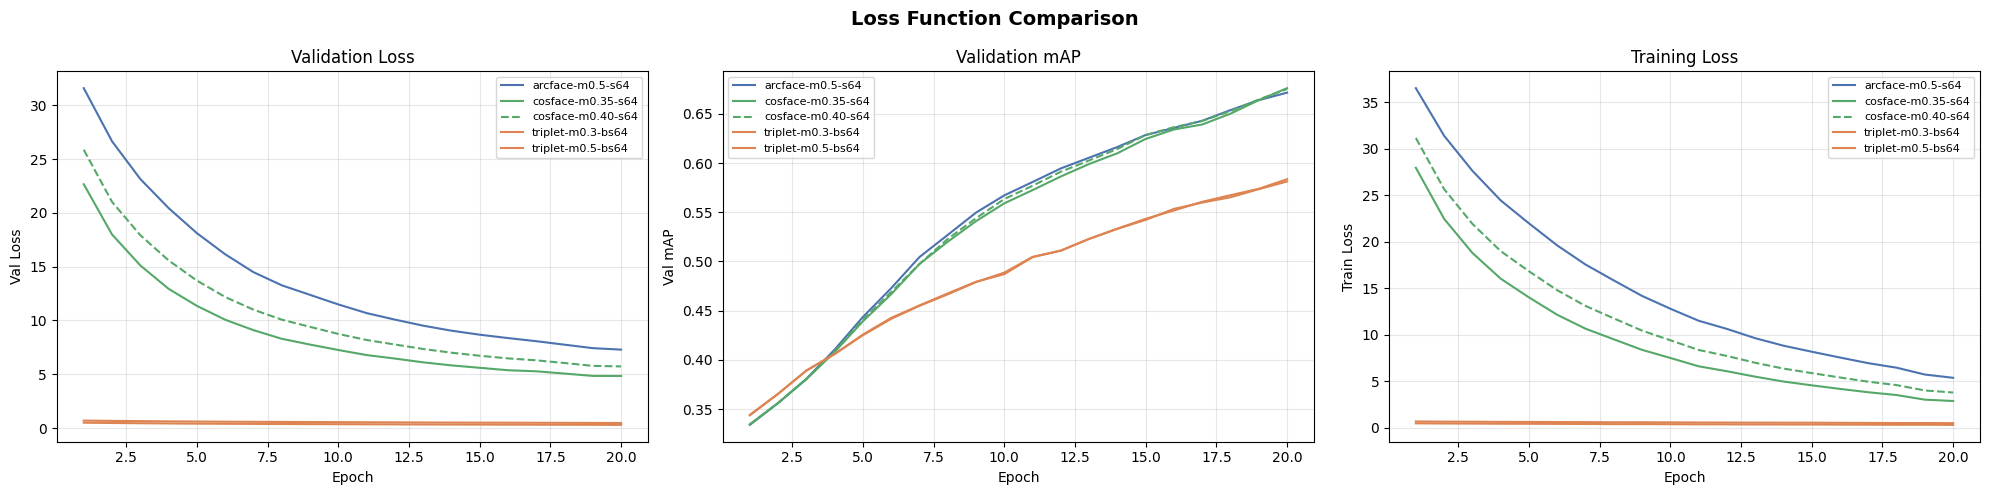

In [15]:
# Visualize sweep results — Val mAP comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Loss Function Comparison", fontsize=14, fontweight='bold')

# Color coding by loss type
loss_colors = {
    "arcface": "#4C72B0",
    "cosface": "#55A868",
    "triplet": "#DD8452",
}

for r in sweep_results:
    label = r['experiment_name']
    color = loss_colors[r['loss_type']]
    epochs = range(1, len(r['history']['train_loss']) + 1)

    axes[0].plot(epochs, r['history']['val_loss'], label=label, color=color,
                 linestyle='-' if 'm0.5' in label or 'm0.35' in label or 'm0.3' in label else '--')
    axes[1].plot(epochs, r['history']['val_map'], label=label, color=color,
                 linestyle='-' if 'm0.5' in label or 'm0.35' in label or 'm0.3' in label else '--')
    axes[2].plot(epochs, r['history']['train_loss'], label=label, color=color,
                 linestyle='-' if 'm0.5' in label or 'm0.35' in label or 'm0.3' in label else '--')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss'); axes[0].set_title('Validation Loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val mAP'); axes[1].set_title('Validation mAP')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train Loss'); axes[2].set_title('Training Loss')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'loss_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

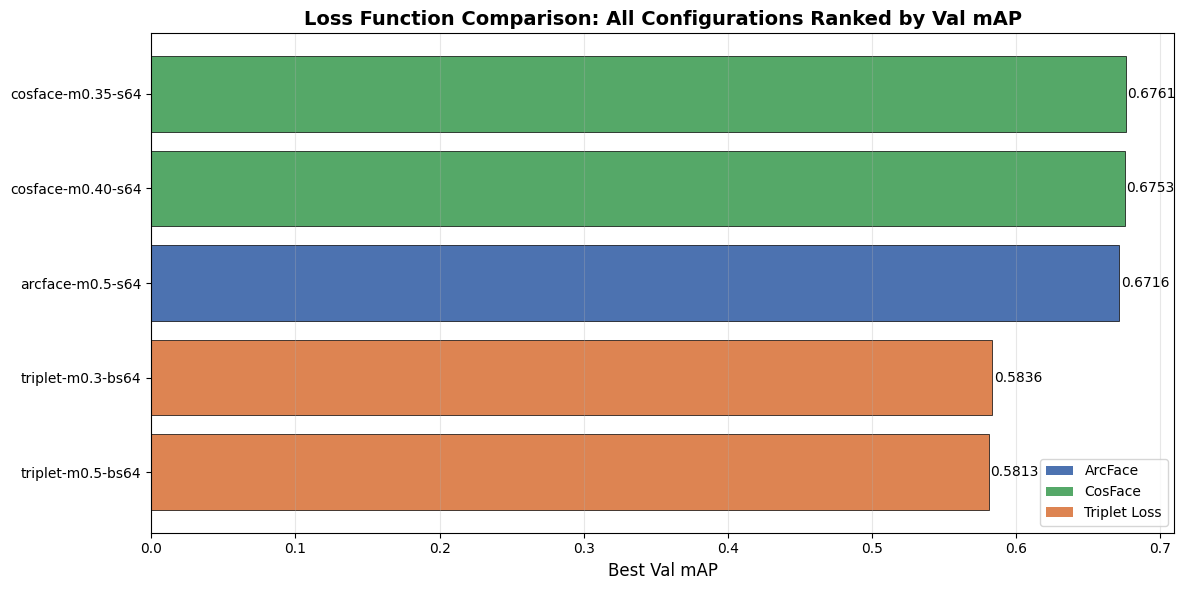

In [16]:
# ── Summary Bar Chart ──
fig, ax = plt.subplots(figsize=(12, 6))

sorted_results = sorted(sweep_results, key=lambda x: x['best_val_map'])
names = [r['experiment_name'] for r in sorted_results]
maps = [r['best_val_map'] for r in sorted_results]
colors = [loss_colors[r['loss_type']] for r in sorted_results]

bars = ax.barh(names, maps, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Best Val mAP', fontsize=12)
ax.set_title('Loss Function Comparison: All Configurations Ranked by Val mAP', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, maps):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=loss_colors["arcface"], label="ArcFace"),
    Patch(facecolor=loss_colors["cosface"], label="CosFace"),
    Patch(facecolor=loss_colors["triplet"], label="Triplet Loss"),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'loss_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full Training with Best Loss Function

Train the best loss function configuration for the full number of epochs, with checkpointing and submission generation.

In [17]:
# ── Full Training with Best Loss Function ──
print("=" * 70)
print("FULL TRAINING: Best Loss Function")
print("=" * 70)

best_cfg = best_loss
loss_type = best_cfg['loss_type']
loss_kwargs = best_cfg['loss_kwargs']

print(f"Loss function: {best_cfg['experiment_name']}")
print(f"Loss type: {loss_type}")
print(f"Loss kwargs: {loss_kwargs}")
print(f"Epochs: {FULL_TRAIN_EPOCHS}")

# Seed
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# W&B run
wandb_config = {k: str(v) if isinstance(v, Path) else v for k, v in base_config.items()}
wandb_config["loss_type"] = loss_type
wandb_config.update(loss_kwargs)

run = wandb.init(
    project=WANDB_PROJECT,
    group="loss-best",
    config=wandb_config,
    name=f"loss-best-{best_cfg['experiment_name']}",
    reinit=True,
)

cfg = base_config
batch_size = loss_kwargs.get("batch_size", cfg["batch_size"])
is_triplet = (loss_type == "triplet")

# Create model
if loss_type == "arcface":
    model = MarginLossModel(
        input_dim=megadescriptor_dim, num_classes=num_classes,
        embedding_dim=cfg["embedding_dim"], hidden_dim=cfg["hidden_dim"],
        margin_layer_class=ArcFaceLayer,
        margin=loss_kwargs.get("margin", 0.5), scale=loss_kwargs.get("scale", 64.0),
        dropout=cfg["dropout"],
    ).to(device)
    criterion = nn.CrossEntropyLoss()
elif loss_type == "cosface":
    model = MarginLossModel(
        input_dim=megadescriptor_dim, num_classes=num_classes,
        embedding_dim=cfg["embedding_dim"], hidden_dim=cfg["hidden_dim"],
        margin_layer_class=CosFaceLayer,
        margin=loss_kwargs.get("margin", 0.35), scale=loss_kwargs.get("scale", 64.0),
        dropout=cfg["dropout"],
    ).to(device)
    criterion = nn.CrossEntropyLoss()
elif loss_type == "triplet":
    model = TripletModel(
        input_dim=megadescriptor_dim,
        embedding_dim=cfg["embedding_dim"], hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    ).to(device)
    criterion = OnlineTripletLoss(margin=loss_kwargs.get("margin", 0.3))

# Dataloaders
train_dataset = EmbeddingDataset(baseline_train_embeddings, train_data['label_encoded'].values)
val_dataset = EmbeddingDataset(baseline_val_embeddings, val_data['label_encoded'].values)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Batch size: {batch_size}")

FULL TRAINING: Best Loss Function
Loss function: cosface-m0.35-s64
Loss type: cosface
Loss kwargs: {'margin': 0.35, 'scale': 64.0}
Epochs: 50


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_182843-krc90bgl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run loss-best-cosface-m0.35-s64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/krc90bgl



Model parameters: 927,744
Batch size: 32


In [18]:
# Full training loop
history = {'train_loss': [], 'val_loss': [], 'val_map': [], 'lr': []}
if not is_triplet:
    history['train_acc'] = []
    history['val_acc'] = []
else:
    history['train_triplets'] = []
    history['val_triplets'] = []

best_val_loss = float('inf')
best_map = 0.0
patience_counter = 0
best_epoch = 0

print(f"\nStarting full training for {FULL_TRAIN_EPOCHS} epochs...")
print("=" * 70)

for epoch in range(FULL_TRAIN_EPOCHS):
    print(f"\nEpoch {epoch+1}/{FULL_TRAIN_EPOCHS}")

    if is_triplet:
        train_loss, train_triplets = train_epoch_triplet(model, train_loader, criterion, optimizer, device)
        val_loss, val_triplets = validate_epoch_triplet(model, val_loader, criterion, device)
        history['train_triplets'].append(train_triplets)
        history['val_triplets'].append(val_triplets)
        print(f"  Train Loss: {train_loss:.4f} | Active Triplets: {train_triplets}")
        print(f"  Val Loss:   {val_loss:.4f} | Active Triplets: {val_triplets}")
    else:
        train_loss, train_acc = train_epoch_margin(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch_margin(model, val_loader, criterion, device)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")

    val_map = compute_validation_map(
        model, baseline_val_embeddings, val_data['ground_truth'].values, device
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    log_dict = {
        'epoch': epoch + 1,
        'train_loss': train_loss, 'val_loss': val_loss,
        'val_map': val_map, 'learning_rate': current_lr,
    }
    if not is_triplet:
        log_dict['train_acc'] = train_acc
        log_dict['val_acc'] = val_acc
    else:
        log_dict['train_active_triplets'] = train_triplets
        log_dict['val_active_triplets'] = val_triplets

    wandb.log(log_dict)

    print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_map = val_map
        best_epoch = epoch + 1
        patience_counter = 0

        checkpoint_path = cfg["checkpoint_dir"] / "best_loss_model.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_map': val_map,
            'loss_type': loss_type,
            'loss_kwargs': loss_kwargs,
            'config': {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()},
            'label_encoder_classes': label_encoder.classes_.tolist(),
            'num_classes': num_classes,
        }, checkpoint_path)
        print(f"  [New best model saved]")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{cfg['patience']}")

    if patience_counter >= cfg['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")

wandb.run.summary["best_val_mAP"] = best_map
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = best_epoch
wandb.run.summary["total_epochs"] = len(history['train_loss'])


Starting full training for 50 epochs...

Epoch 1/50
  Train Loss: 27.9494 | Train Acc: 0.0%
  Val Loss:   22.6552 | Val Acc:   0.0%
  Val mAP:    0.3344 | LR: 1.00e-04
  [New best model saved]

Epoch 2/50
  Train Loss: 22.4547 | Train Acc: 0.1%
  Val Loss:   17.9877 | Val Acc:   8.4%
  Val mAP:    0.3561 | LR: 1.00e-04
  [New best model saved]

Epoch 3/50
  Train Loss: 18.7882 | Train Acc: 3.0%
  Val Loss:   15.1131 | Val Acc:   14.5%
  Val mAP:    0.3803 | LR: 1.00e-04
  [New best model saved]

Epoch 4/50
  Train Loss: 16.0226 | Train Acc: 8.2%
  Val Loss:   12.9394 | Val Acc:   20.6%
  Val mAP:    0.4080 | LR: 1.00e-04
  [New best model saved]

Epoch 5/50
  Train Loss: 14.0058 | Train Acc: 12.2%
  Val Loss:   11.3590 | Val Acc:   31.7%
  Val mAP:    0.4392 | LR: 1.00e-04
  [New best model saved]

Epoch 6/50
  Train Loss: 12.1333 | Train Acc: 17.5%
  Val Loss:   10.0714 | Val Acc:   39.3%
  Val mAP:    0.4667 | LR: 1.00e-04
  [New best model saved]

Epoch 7/50
  Train Loss: 10.6386 |

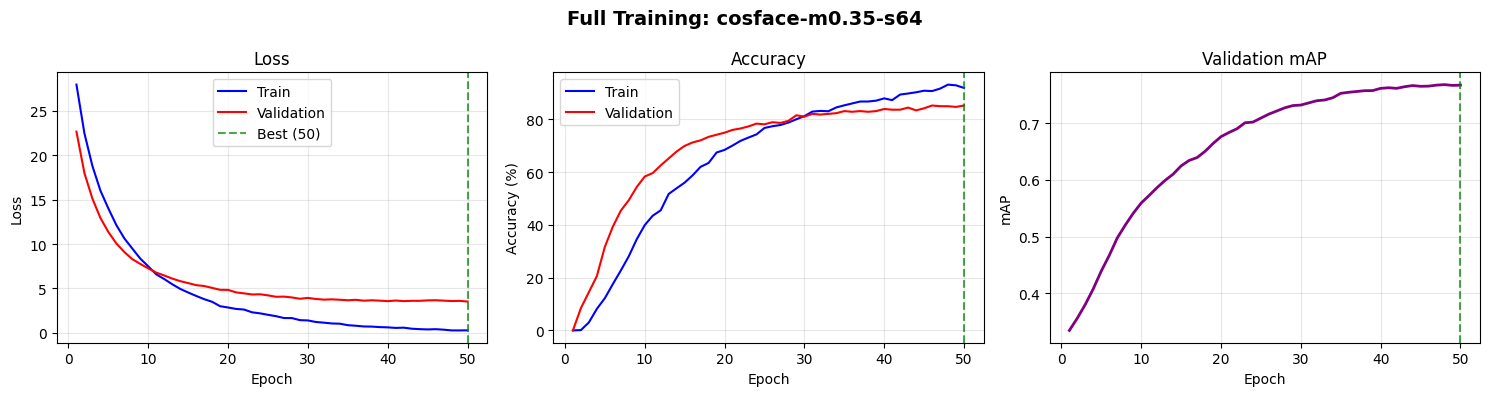

In [19]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Full Training: {best_cfg['experiment_name']}", fontsize=14, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

if not is_triplet:
    axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
    axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
else:
    axes[1].plot(epochs_range, history['train_triplets'], 'b-', label='Train')
    axes[1].plot(epochs_range, history['val_triplets'], 'r-', label='Validation')
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Active Triplets'); axes[1].set_title('Active Triplets')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('mAP'); axes[2].set_title('Validation mAP')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(cfg["checkpoint_dir"] / 'full_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({"training_curves": wandb.Image(fig)})

## 9. Visualize Fine-tuned Embeddings

In [20]:
# Load best model
checkpoint = torch.load(cfg["checkpoint_dir"] / "best_loss_model.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 50
  Val Loss: 3.5315
  Val mAP: 0.7670


In [21]:
# Extract fine-tuned embeddings
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_train_embeddings).to(device)
    finetuned_train_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1516, 256)
Mean L2 norm: 1.0000


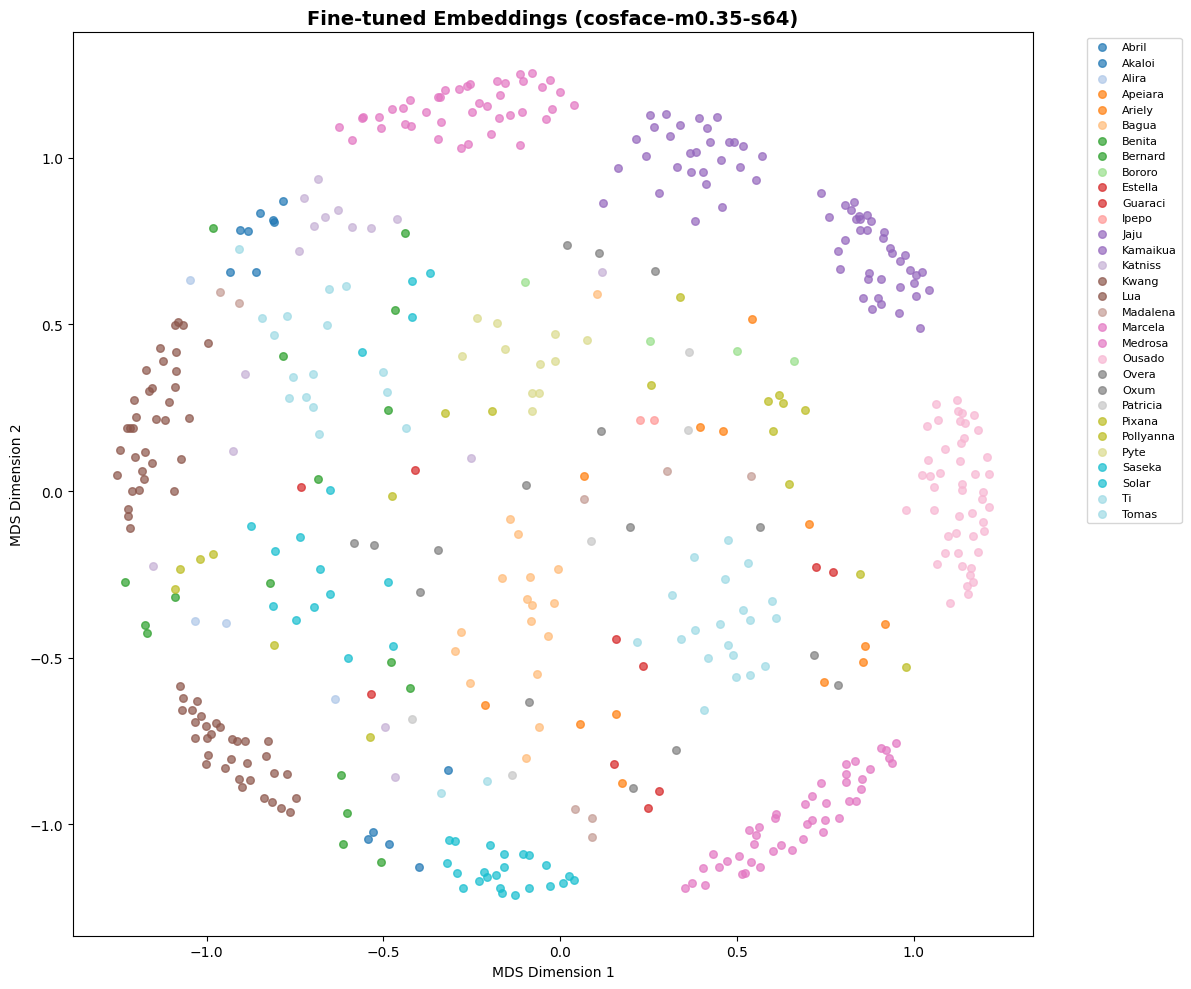

In [22]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    geodesic_dist = np.arccos(cos_sim)
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]

    dist_matrix = compute_geodesic_distances(embeddings)
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)

    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(12, 10))
    for label in unique_labels:
        mask = labels == label
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], c=[label_to_color[label]], label=label, alpha=0.7, s=30)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig


# Visualize
train_labels = train_data['ground_truth'].values
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings, train_labels,
    f"Fine-tuned Embeddings ({best_cfg['experiment_name']})"
)
plt.show()
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

## 10. Generate Competition Submission

In [23]:
# Load test data
test_pairs_df = pd.read_csv(cfg["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [24]:
# Get unique test images and extract embeddings
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

test_image_paths = [cfg["data_dir"] / "test" / "test" / filename for filename in test_images]

print(f"\nExtracting MegaDescriptor embeddings for test images...")
test_mega_embeddings = extract_embeddings(
    megadescriptor, test_image_paths, batch_size=cfg["batch_size"], desc="Test embeddings"
)

# Get fine-tuned test embeddings
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")

Unique test images: 371

Extracting MegaDescriptor embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Fine-tuned test embeddings shape: (371, 256)


In [25]:
# Compute similarities and create submission
img_to_embedding = {fn: emb for fn, emb in zip(test_images, test_finetuned_embeddings)}

print("Computing pairwise similarities...")
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

# Create submission
submission_df = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
print(f"\nSubmission DataFrame:")
print(submission_df.head(10))

# Verify format
sample_submission = pd.read_csv(cfg["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9934
  Mean: 0.0564
  Std: 0.1103

Submission DataFrame:
   row_id  similarity
0       0    0.648547
1       1    0.000000
2       2    0.000000
3       3    0.000000
4       4    0.000000
5       5    0.000000
6       6    0.007665
7       7    0.000000
8       8    0.000000
9       9    0.131410

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [26]:
# Save submission
submission_path = cfg["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: checkpoints_loss/submission.csv
File size: 1817.9 KB


## 11. Save Artifacts and Finish

In [27]:
# Save model as W&B artifact
model_artifact = wandb.Artifact(
    name="loss-experiment-model",
    type="model",
    description=f"Best loss function model ({best_cfg['experiment_name']})"
)
model_artifact.add_file(str(cfg["checkpoint_dir"] / "best_loss_model.pth"))
wandb.log_artifact(model_artifact)

print("Model artifact saved to W&B")

# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission-loss-experiment",
    type="submission",
    description=f"Competition submission from loss function experiment ({best_cfg['experiment_name']})"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Model artifact saved to W&B
Submission artifact saved to W&B


In [28]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

wandb: uploading artifact loss-experiment-model; uploading artifact submission-loss-experiment; updating run metadata
wandb: uploading artifact loss-experiment-model; uploading artifact submission-loss-experiment
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
wandb: learning_rate █████████████████████████████████████▁▁▁
wandb:     train_acc ▁▁▁▂▂▃▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████
wandb:    train_loss █▇▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▂▂▃▄▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
wandb:      val_loss █▆▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_map ▁▁▂▂▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
wandb: 
wandb: Run summary:
wandb:    best_epoch 50
wandb: best_val_loss 3.53149
wandb:  best_val_mAP 0.76695
wandb:         epoch 50
wandb: learning_rate 5e-05
wandb:  total_epochs 50
wandb:     train_acc 91.88654
wandb:    train_loss 0.28958
wandb:       val_acc 85.22427
wandb:      val_loss 3.53149
wandb:            +1 .

W&B run completed


## Summary

This notebook performed a **systematic comparison of loss functions** on the baseline pipeline (MegaDescriptor + EmbeddingProjection):

### Loss Functions Compared
1. **ArcFace** (m=0.5, s=64) — Additive Angular Margin (baseline)
2. **CosFace** (m=0.35, s=64) — Additive Cosine Margin (standard)
3. **CosFace** (m=0.40, s=64) — Additive Cosine Margin (larger margin)
4. **Triplet Loss** (m=0.3, bs=64) — Online Hard Mining
5. **Triplet Loss** (m=0.5, bs=64) — Online Hard Mining (larger margin)

### Key Differences Between Losses
- **ArcFace** adds margin in **angular space**: $\cos(\theta + m)$ — penalizes the angle to the ground truth class center
- **CosFace** adds margin in **cosine space**: $\cos(\theta) - m$ — simpler but effective, no trigonometric computation
- **Triplet Loss** optimizes **relative distances**: requires mining hard (anchor, positive, negative) triplets per batch

### Methodology
- Each loss function trained for 20 epochs (reduced from 50) for efficiency
- Best loss function trained for full 50 epochs with checkpointing
- All metrics logged to W&B for comparison

### Controlled Variables
- Same MegaDescriptor-L-384 backbone (frozen)
- Same EmbeddingProjection architecture (1536 → 512 → 256)
- Same data (no augmentation)
- Same train/val split (stratified, seed=42)
- Same validation mAP computation
- Same optimizer (AdamW, lr=1e-4) and scheduler (ReduceLROnPlateau)
- Same W&B logging

### How to Compare
- W&B dashboard: filter by group `loss-comparison` to see all sweep runs
- Compare `best_val_mAP` across runs
- Final model: group `loss-best`
- Baseline comparison: `megadescriptor-arcface-local` (original baseline)